# Dataset Exploration

Initial notebook to inspect the **Balanced RAF-DB grayscale** dataset used in the *Privacy-Preserving Facial Expression Recognition* project.

This notebook helps us:
- verify the dataset structure;
- inspect class balance across splits;
- preview random samples;
- check basic image properties before training.

In [1]:
from pathlib import Path
import random
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "balanced-raf-db-dataset-7575-grayscale"
SPLITS = ["train", "val", "test"]
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

DATASET_DIR

WindowsPath('C:/Users/Tiago/Documents/GitHub/privacy-fer/data/raw/balanced-raf-db-dataset-7575-grayscale')

In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

split_summary = []

for split in SPLITS:
    split_path = DATASET_DIR / split
    class_names = sorted([path.name for path in split_path.iterdir() if path.is_dir()])
    split_summary.append(
        {
            "split": split,
            "num_classes": len(class_names),
            "classes": ", ".join(class_names),
        }
    )

pd.DataFrame(split_summary)

,split,num_classes,classes
0,train,7,"angry, disgust, fear, happy, neutral, sad, sur..."
1,val,7,"angry, disgust, fear, happy, neutral, sad, sur..."
2,test,7,"angry, disgust, fear, happy, neutral, sad, sur..."


In [3]:
records = []

for split in SPLITS:
    split_path = DATASET_DIR / split
    class_dirs = sorted([path for path in split_path.iterdir() if path.is_dir()])

    for class_dir in class_dirs:
        image_paths = sorted([path for path in class_dir.iterdir() if path.is_file()])

        for image_path in image_paths:
            records.append(
                {
                    "split": split,
                    "label": class_dir.name,
                    "filename": image_path.name,
                    "image_path": str(image_path),
                }
            )

images_df = pd.DataFrame(records)

print(f"Total images: {len(images_df):,}")
images_df.head()

Total images: 41,692


,split,label,filename,image_path
0,train,angry,aug_100959.png,C:\Users\Tiago\Documents\GitHub\privacy-fer\da...
1,train,angry,aug_101643.png,C:\Users\Tiago\Documents\GitHub\privacy-fer\da...
2,train,angry,aug_101669.png,C:\Users\Tiago\Documents\GitHub\privacy-fer\da...
3,train,angry,aug_101718.png,C:\Users\Tiago\Documents\GitHub\privacy-fer\da...
4,train,angry,aug_101896.png,C:\Users\Tiago\Documents\GitHub\privacy-fer\da...


In [4]:
class_counts = (
    images_df.groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
)

class_counts_pivot = (
    class_counts.pivot(index="label", columns="split", values="count")
    .fillna(0)
    .astype(int)
    .reindex(columns=SPLITS)
)

class_counts_pivot

split,train,val,test
label,,,
angry,4289,1072,595
disgust,4289,1072,595
fear,4289,1072,595
happy,4289,1072,595
neutral,4289,1072,595
sad,4289,1072,595
surprise,4289,1072,595


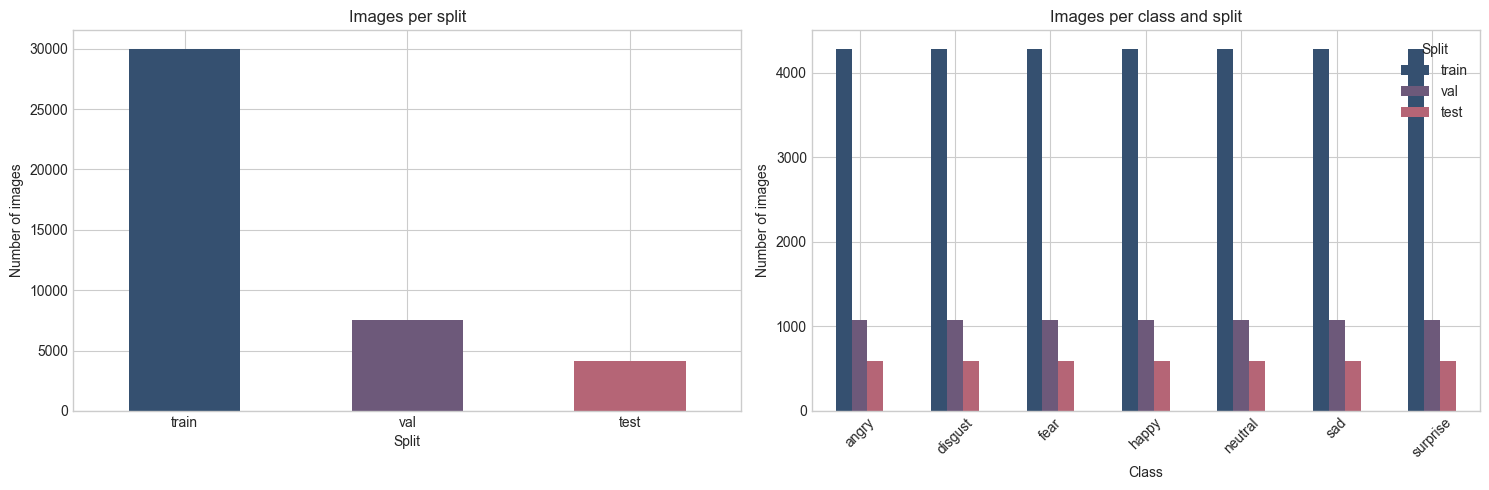

In [5]:
split_counts = images_df["split"].value_counts().reindex(SPLITS).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

split_counts.plot(kind="bar", ax=axes[0], color=["#355070", "#6d597a", "#b56576"])
axes[0].set_title("Images per split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=0)

class_counts_pivot.plot(kind="bar", ax=axes[1], color=["#355070", "#6d597a", "#b56576"])
axes[1].set_title("Images per class and split")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of images")
axes[1].legend(title="Split")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
file_extensions = (
    images_df["filename"].str.rsplit(".", n=1).str[-1].str.lower().value_counts().rename("count")
)

shape_sample = images_df.sample(n=min(len(images_df), 1000), random_state=RANDOM_SEED)
shape_records = []

for image_path in shape_sample["image_path"]:
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if image is None:
        continue

    if image.ndim == 2:
        height, width = image.shape
        channels = 1
    else:
        height, width, channels = image.shape

    shape_records.append(
        {
            "height": height,
            "width": width,
            "channels": channels,
        }
    )

print("File extensions:")
print(file_extensions)
print()
print("Sampled image shape summary:")
pd.DataFrame(shape_records).describe().T

File extensions:
filename
png    29421
jpg    12271
Name: count, dtype: int64

Sampled image shape summary:


,count,mean,std,min,25%,50%,75%,max
height,1000.0,75.0,0.0,75.0,75.0,75.0,75.0,75.0
width,1000.0,75.0,0.0,75.0,75.0,75.0,75.0,75.0
channels,1000.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


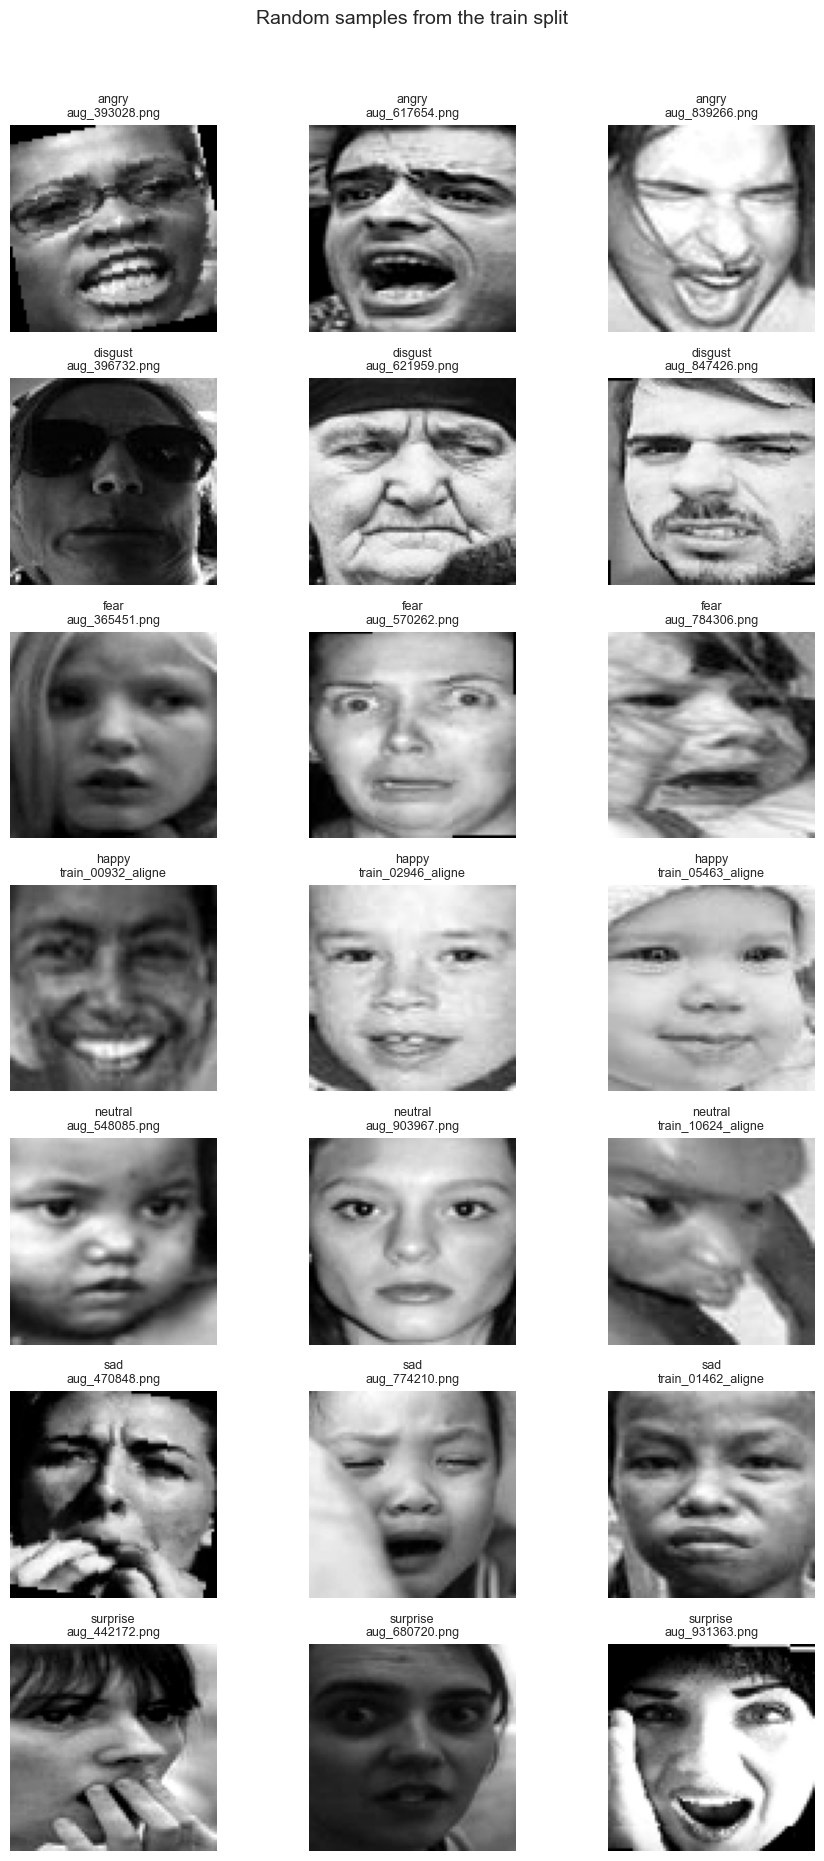

: 

In [ ]:
def plot_random_samples(dataframe, split="train", samples_per_class=3):
    labels = sorted(dataframe["label"].unique())
    fig, axes = plt.subplots(len(labels), samples_per_class, figsize=(3.2 * samples_per_class, 2.6 * len(labels)))

    if len(labels) == 1:
        axes = [axes]

    for row, label in enumerate(labels):
        subset = dataframe[(dataframe["split"] == split) & (dataframe["label"] == label)]
        sample_count = min(samples_per_class, len(subset))
        sample_df = subset.sample(n=sample_count, random_state=RANDOM_SEED)

        current_axes = [axes[row]] if samples_per_class == 1 else axes[row]

        for col, ax in enumerate(current_axes):
            if col < sample_count:
                image_path = sample_df.iloc[col]["image_path"]
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                ax.imshow(image, cmap="gray")
                ax.set_title(f"{label}\n{Path(image_path).name[:18]}", fontsize=9)
            ax.axis("off")

    fig.suptitle(f"Random samples from the {split} split", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_random_samples(images_df, split="train", samples_per_class=3)

## Suggested Next Checks

- compare the same class across `train`, `val`, and `test`;
- inspect whether all images are truly grayscale and have the same size;
- prototype privacy filters from `src/privacy_filters.py` and visualize the transformed outputs;
- build a PyTorch dataset loader after validating the folder structure.